In [ ]:
##调试单个模型， 只需修改test_file_path和model_path

test_file_path = 'data_cleaned/ver-noelectrolyte-logtransform_mean.csv'
model_path = 'trained_models/mean/DecisionTree_0.53.pkl'

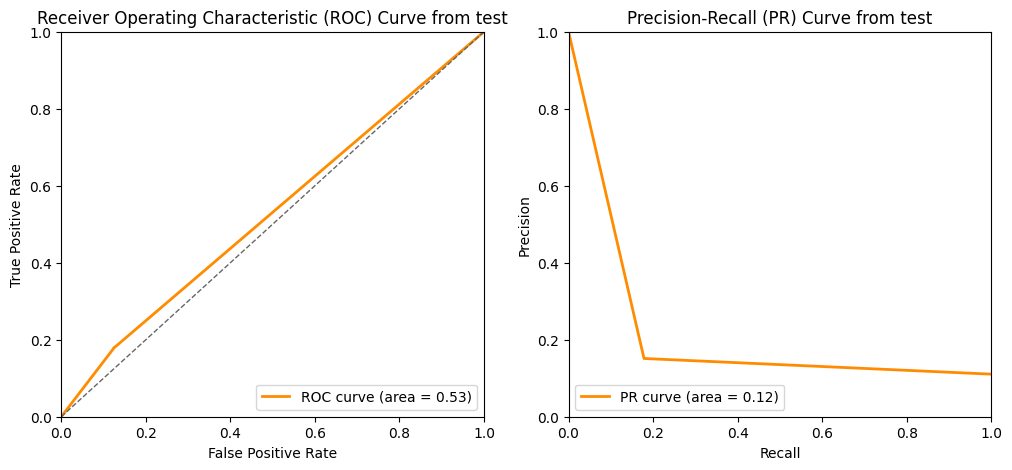

AUROC: 0.5270
AUPRC: 0.1178
[np.float64(0.5270239310771696), np.float64(0.5222671144382589), np.float64(0.5317243262550326), 0.7983918863356023, 0.17851239669421487, 0.8754430119677435, 0.1512075603780189, 0.8955443463640185, 0.16372939169982945]


In [4]:
import ehr_utils
X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(test_file_path, train_size=0.8, random_state=42)
model = ehr_utils.load_model(model_path)
Y_prob,Y_pred = ehr_utils.get_prediction_results(model,X_test)
ehr_utils.plot_roc_pr_curves(Y_test,Y_prob,'dt')
print(ehr_utils.eval_model(Y_test, Y_pred, Y_prob))

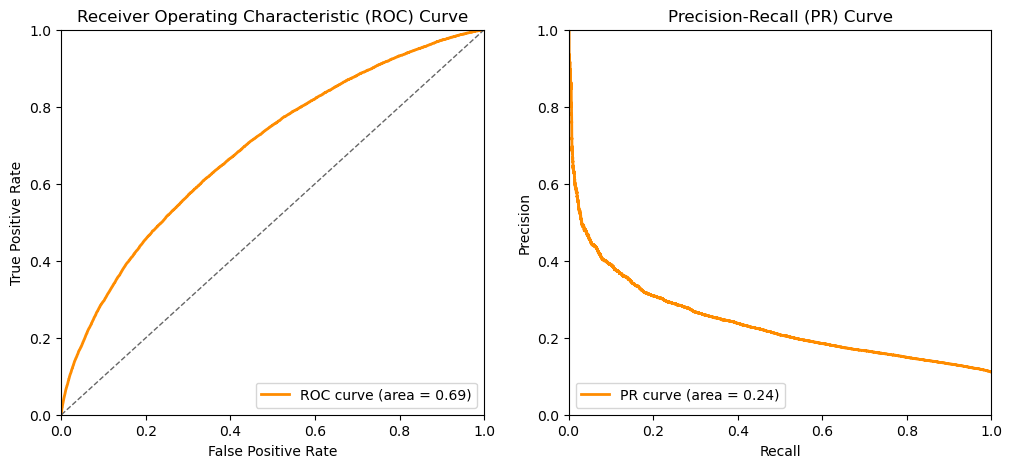

AUROC: 0.6893
AUPRC: 0.2401


In [4]:
ehr_utils.plot_roc_pr_curves(Y_test, Y_pred_proba, model_name='xgb_model')

In [ ]:

xxx=[1,2,3]
yyy=[1,0,0]
zzz=[1,1,1]
x1,x2,x3,x4,x5,x6 = train_test_split(xxx,yyy,zzz, train_size=0.8, random_state=42)
print(x1,x2,x3,x4,x5,x6)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from ehr_utils import plot_roc_pr_curves
# 生成模拟数据
X, y = make_classification(n_samples=120, n_features=20, n_classes=2, random_state=42)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 训练模型
model = LogisticRegression()
model.fit(X_train, y_train)

# 获取模型预测的概率
y_pred_proba = model.predict_proba(X_test)[:, 1]

plot_roc_pr_curves(y_test,y_pred_proba)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

# Simulate data from a bivariate Gaussian
n = 10000
mean = [0, 0]
cov = [(2, .4), (.4, .2)]
rng = np.random.RandomState(0)
x, y = rng.multivariate_normal(mean, cov, n).T

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=50, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)